## **Project Description**

The objective of this project is to analyze patient drug reviews and identify sentiment patterns based on review text. The dataset contains patient reviews, drug names, medical conditions, ratings, review dates, and useful vote counts. Since the dataset does not include a direct sentiment column, sentiment analysis is performed using a pre-trained RoBERTa model to classify reviews as negative, neutral, or positive.

In addition to sentiment analysis, dimensionality reduction and K-Means clustering are used to explore similarities among reviews and identify common review patterns.


## Metadata

The dataset used in this project is the [Drug Review Data](https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018) from Kaggle. It includes the following columns:

- `uniqueID`: A unique identifier for each review.
- `drugName`: The name of the drug being reviewed.
- `condition`: The medical condition associated with the drug.
- `review`: The written patient review describing the medication experience.
- `rating`: The user rating for the drug, ranging from 1 to 10.
- `date`: The date when the review was posted.
- `usefulCount`: The number of users who found the review helpful.

## What my Portfolio will present:
1. What the dataset contains
2. Which conditions and drugs appear most often
3. How ratings are distributed
4. How the dataset was cleaned
5. How RoBERTa classified reviews into sentiment categories
6. How review text was reduced into lower dimensions
7. How K-Means grouped similar reviews
8. What each cluster appears to represent



#Table of Contents

1. [Initial Look](#intl)
2. [Exploratory Data Analysis](#eda)
3. [Data Cleaning](#dc)
4. [Data Preprocessing](#proc)
5. [Sentiment Analysis using RoBERTa](#sdp)
6. [Dimensionality Reduction](#dimr)
7. [Elbow Method](#em)
8. [K-Means Clustering](#kmean)
9. [Cluster Insights](#edac)
10. [Conclusion](#conc)

#1. Initial Look at the Dataset <a name= "intl"></a>

In [ ]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile as zf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Extracting Dataset

zip_file_path = r'/content/drive/MyDrive/Drug Review/archive (8).zip'
file_folder_path = r'/content/drive/MyDrive/Drug Review/'

with zf.ZipFile(zip_file_path) as reference:
  reference.extractall(file_folder_path)

In [ ]:
# Loading train and test datasets

test_file_path = r'/content/drive/MyDrive/Drug Review/drugsComTest_raw.csv'
train_file_path = r'/content/drive/MyDrive/Drug Review/drugsComTrain_raw.csv'

train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

**The dataset is divided into training and testing files. The training set will be used for data exploration, preprocessing, feature engineering, dimensionality reduction, clustering, and model training. The testing set will be reserved for final model evaluation.**

In [ ]:
# Checking for the df shape

print("Training dataset shape:", train_df.shape)  # for data exploration, preprocessing, feature engineering, dimensionality reduction, clustering, and model training
print("Testing dataset shape:", test_df.shape)    # reserved for final model evaluation.

Training dataset shape: (161297, 7)
Testing dataset shape: (53766, 7)


In [ ]:
train_df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get ou...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not ava...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth control. I&#039;m glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around. I feel healthier, I&#039;m excelling at my job and I always have money in my pocket and my savings account. I had none of those before Suboxone an...",9,27-Nov-16,37


In [ ]:
# Checking for Rows and Columns of TRAINING SET

rows, columns = train_df.shape
print('Number of Rows:', rows)
print('Number of Columns:', columns)

Number of Rows: 161297
Number of Columns: 7


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [ ]:
# Detecting for Missing Values

train_df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,899
review,0
rating,0
date,0
usefulCount,0


In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
uniqueID,161297.0,115923.585305,67004.445170,2.0,58063.0,115744.0,173776.0,232291.0
rating,161297.0,6.994377,3.272329,1.0,5.0,8.0,10.0,10.0
usefulCount,161297.0,28.004755,36.403742,0.0,6.0,16.0,36.0,1291.0


In [ ]:
train_df.describe(include='object').T

,count,unique,top,freq
drugName,161297,3436,Levonorgestrel,3657
condition,160398,884,Birth Control,28788
review,161297,112329,"""Good""",33
date,161297,3579,1-Mar-16,146


**The .T transposes the descriptive statistics table, making each feature appear as a row. This format is easier to read when comparing count, mean, standard deviation, minimum, quartiles, and maximum values across numerical features.**

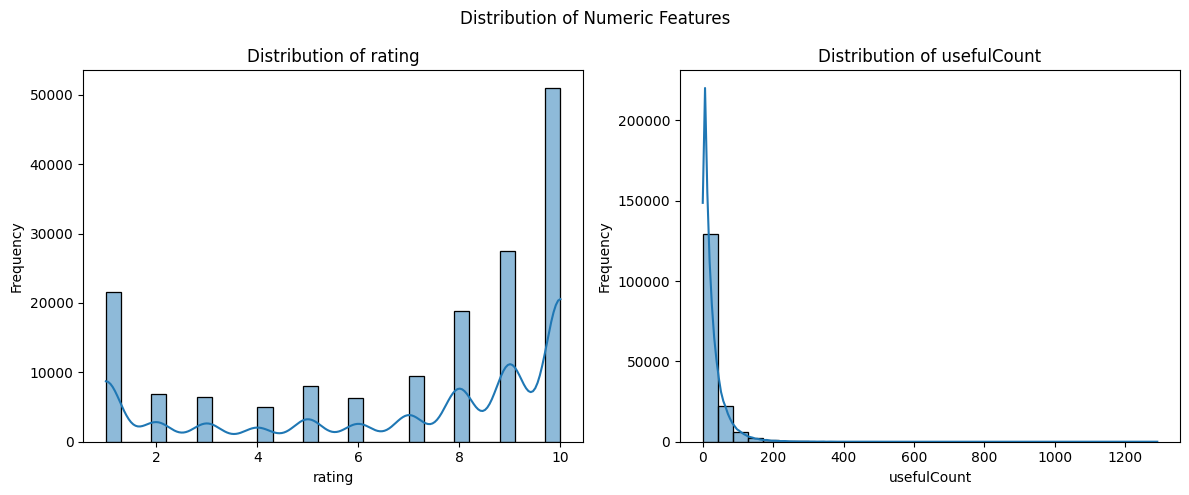

In [ ]:
# Plotting for Numerical Counts

numeric_cols = ['rating', 'usefulCount']

fig, axes = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(data=train_df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.suptitle('Distribution of Numeric Features')
plt.tight_layout()
plt.show()

**Only rating and usefulCount were visualized as numerical distributions because uniqueID is an identifier and does not represent a meaningful measurable feature.**

The rating distribution is concentrated toward higher ratings, especially 10, suggesting many positive user experiences. However, rating 1 is also common, showing the presence of strongly negative reviews. The usefulCount distribution is right-skewed, where most reviews have low usefulness votes and only a few reviews have very high counts. This indicates that user engagement is uneven across reviews.

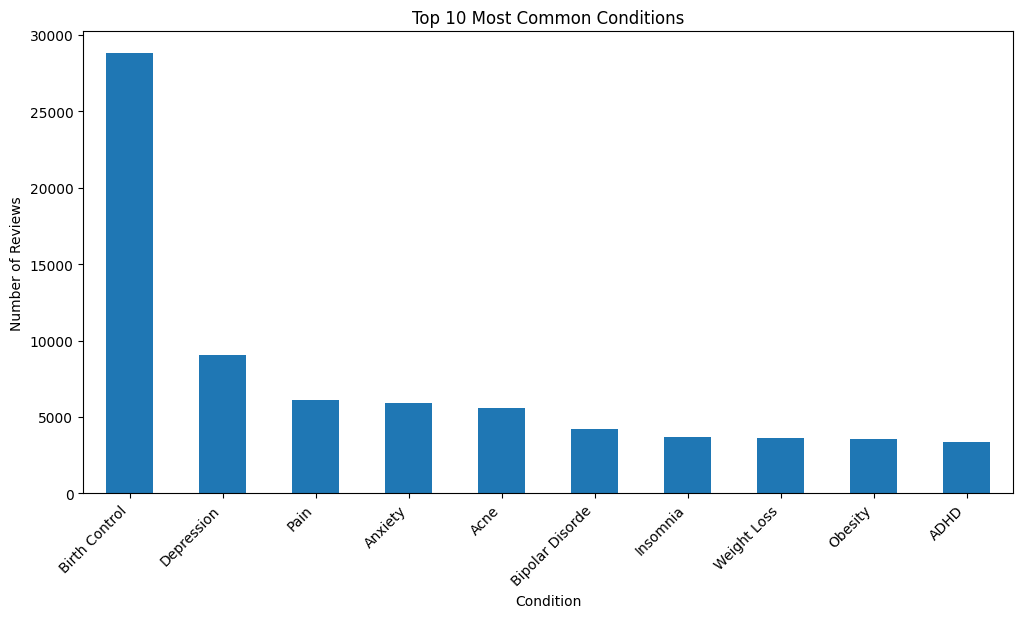

In [ ]:
# Plotting for Categorical Counts
# For the Most Common Condition  in the Dataset

plt.figure(figsize=(12, 6))
train_df['condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Common Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight: Top 10 Most Common Conditions**

Birth Control is the most common condition in the dataset by a large margin, followed by Depression, Pain, Anxiety, and Acne. This shows that the dataset is not evenly distributed across medical conditions. The dominance of Birth Control reviews may influence later analysis, especially sentiment modeling and clustering, because patterns from this condition may have a stronger effect on the overall results.

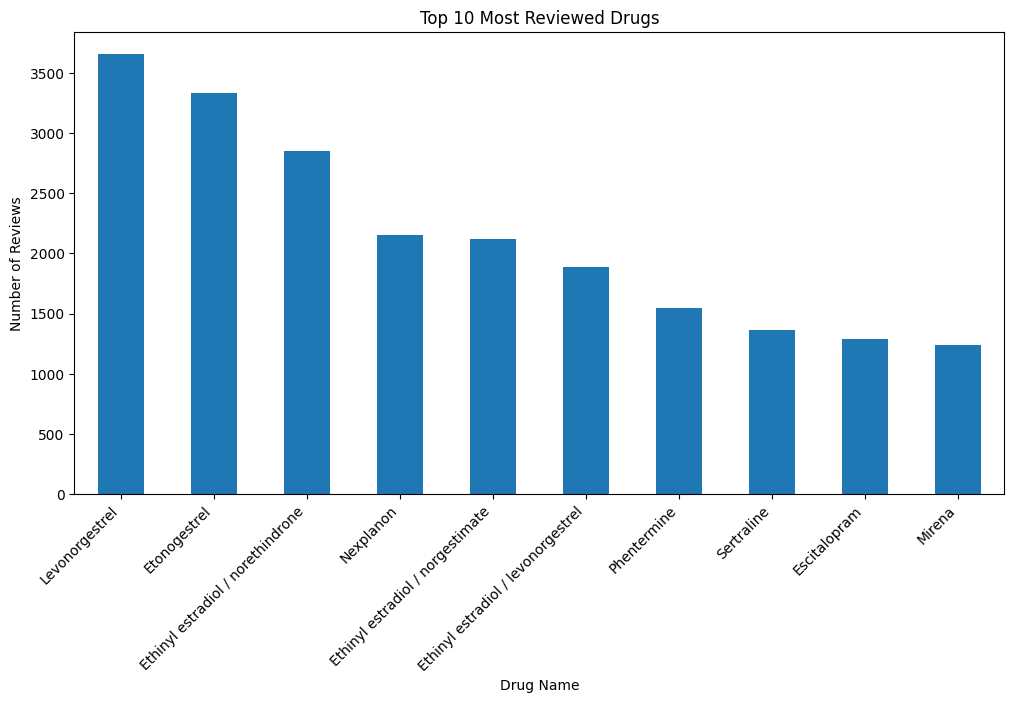

In [ ]:
# Plotting for Categorical Counts
# For the Most Reviewed Drugs in the Dataset

plt.figure(figsize=(12, 6))
train_df['drugName'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Reviewed Drugs')
plt.xlabel('Drug Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight: Top 10 Most Reviewed Drugs**

The most reviewed drugs are mostly associated with birth control, which supports the finding that Birth Control is the dominant condition in the dataset. Drugs such as Levonorgestrel, Etonogestrel, and Nexplanon appear among the most reviewed medications. Antidepressants such as Sertraline and Escitalopram also appear, reflecting the large number of reviews related to Depression and Anxiety.

# 2. Exploratory Data Analysis <a name="eda"></a>
    2.1 Rating Distribution
    2.2 Top 10 Most Common Conditions
    2.3 Top 10 Most Reviewed Drugs
    2.4 Average Rating by Condition
    2.5 Lowest Average Rating by Condition
    2.6 Useful Count by Rating
    2.7 Review Length Distribution
    2.8 Review Length by Rating



**2.1  Rating Distribution**

This graph shows how the ratings are distributed from 1 to 10. Most reviews are highly positive, especially rating 10, but there is also a large number of rating 1 reviews. This means users often give extreme feedback, either very satisfied or very dissatisfied. This is important because I will later use ratings to create sentiment labels, so I need to be aware that the positive class may dominate the dataset.

Text(0, 0.5, 'Nr of Reviews')

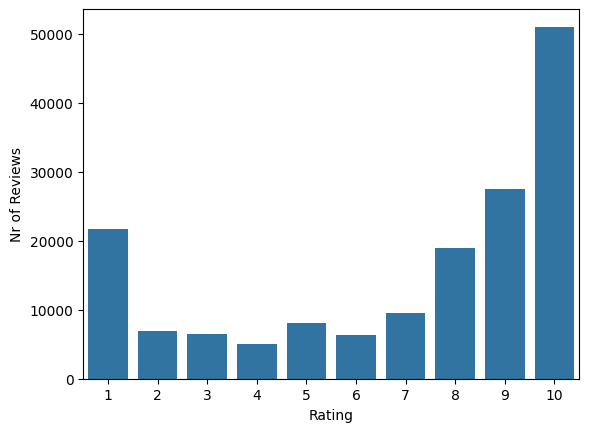

In [ ]:
# Let us counts how many reviews exist for each rating value.

sns.countplot(data=train_df, x='rating')
plt.xlabel('Rating')
plt.ylabel('Nr of Reviews')

**2.2 Top 10 Most Common Conditions**

Birth Control is the most common condition in the dataset by a large margin, followed by Depression, Pain, Anxiety, and Acne. This shows that the dataset is not evenly distributed across medical conditions. The dominance of Birth Control reviews may influence later analysis, especially sentiment modeling and clustering, because patterns from this condition may have a stronger effect on the overall results.

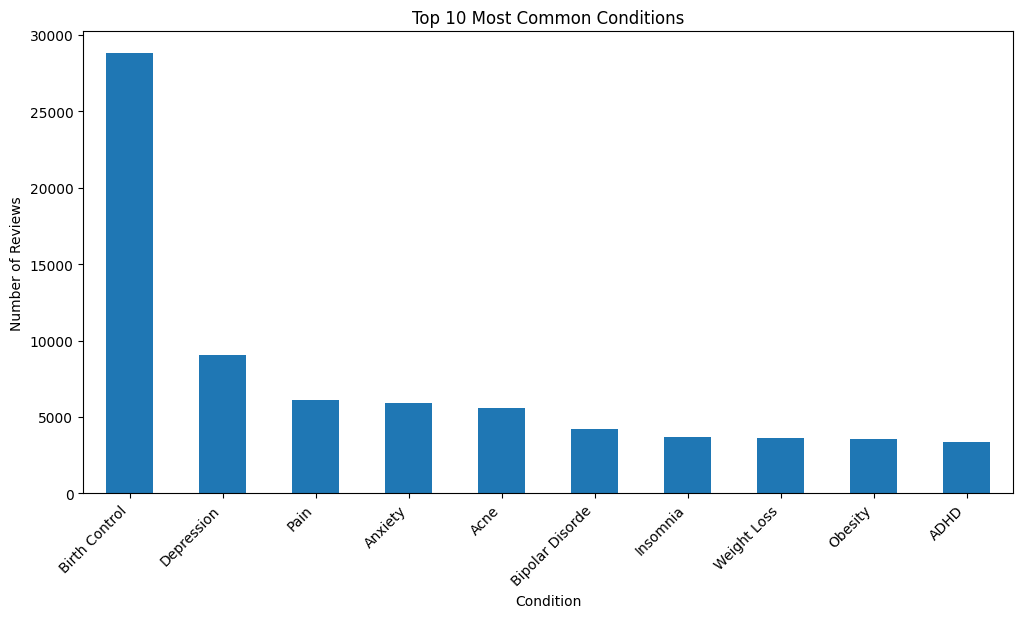

In [ ]:
plt.figure(figsize=(12, 6))
train_df['condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Common Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

**2.3 Top 10 Most Reviewed Drugs**

The most reviewed drugs are mostly associated with birth control, which supports the finding that Birth Control is the dominant condition in the dataset. Drugs such as Levonorgestrel, Etonogestrel, and Nexplanon appear among the most reviewed medications. Antidepressants such as Sertraline and Escitalopram also appear, reflecting the large number of reviews related to Depression and Anxiety.

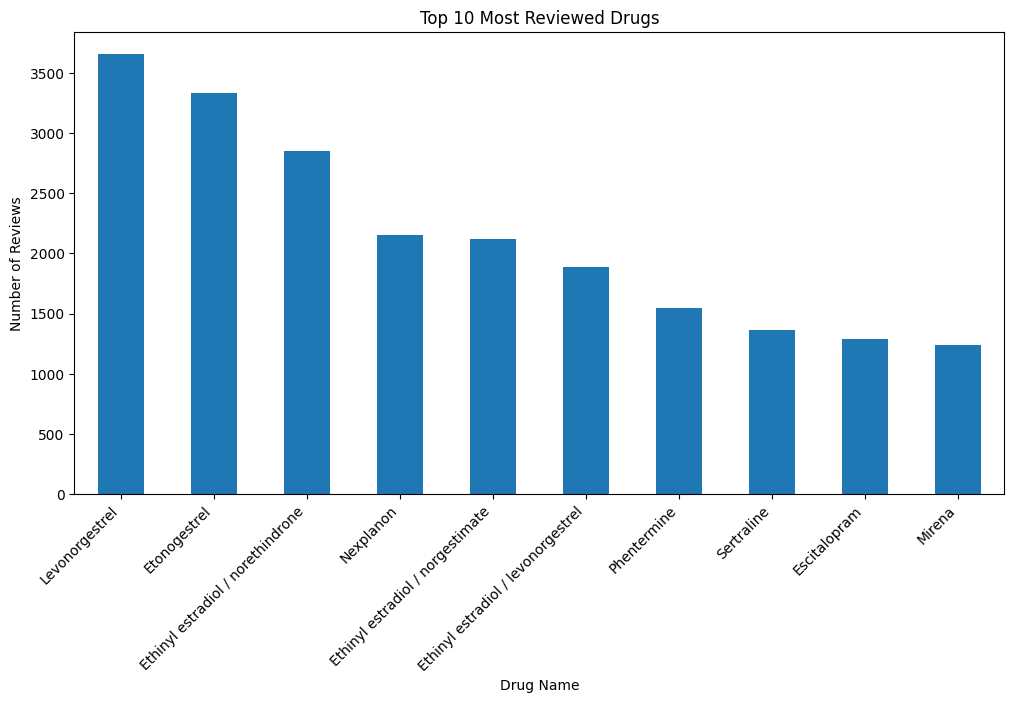

In [ ]:
plt.figure(figsize=(12, 6))
train_df['drugName'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Reviewed Drugs')
plt.xlabel('Drug Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

**2.4 Average Rating by Condition**

In [ ]:
# Group the dataset by condition, then calculate summary statistics for each condition.

condition_stats = train_df.groupby('condition').agg(
    average_rating=('rating', 'mean'),
    review_count=('rating', 'count'),
    average_useful_count=('usefulCount', 'mean')
).reset_index()

condition_stats.head()

,condition,average_rating,review_count,average_useful_count
0,0</span> users found this comment helpful.,5.884615,104,0.0
1,10</span> users found this comment helpful.,7.071429,28,10.0
2,110</span> users found this comment helpful.,9.000000,1,110.0
3,11</span> users found this comment helpful.,7.100000,10,11.0
4,121</span> users found this comment helpful.,6.000000,1,121.0


In [ ]:
condition_stats_filtered = condition_stats[condition_stats['review_count'] >= 100]

Here, I grouped the dataset by condition and calculated the average rating and number of reviews for each condition. I filtered out conditions with fewer than 100 reviews because a condition with only one perfect rating could misleadingly appear as top-rated

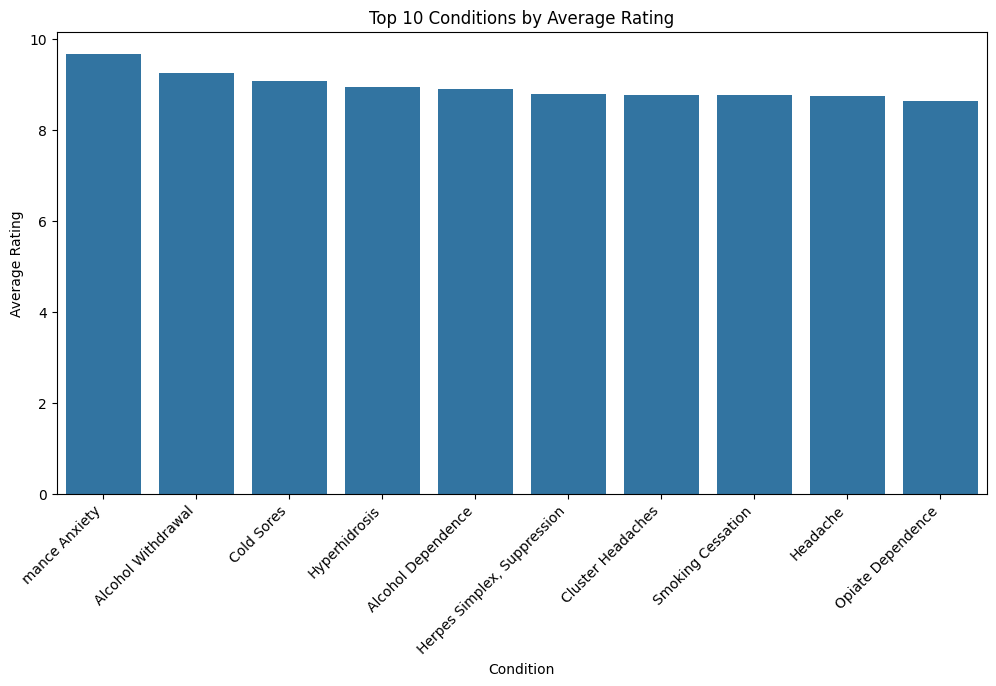

In [ ]:
top_conditions_rating = condition_stats_filtered.sort_values(
    by='average_rating',
    ascending=False  # sort from largest to smallest
).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_conditions_rating, x='condition', y='average_rating')
plt.title('Top 10 Conditions by Average Rating')
plt.xlabel('Condition')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

 The chart shows that Performance Anxiety, Alcohol Withdrawal, and Cold Sores have some of the highest average ratings among frequently reviewed conditions. I also noticed some invalid condition values, which will be addressed in the preprocessing step.

**2.5 Lowest Average Rating by Condition**

In [ ]:
lowest_conditions_rating = condition_stats_filtered.sort_values(
    by='average_rating',
    ascending=True # sort from smallest to largest
).head(10)

This graph uses the same grouped condition statistics as the previous chart, but instead of sorting from highest to lowest, I sorted from lowest to highest using ascending=True. This allows me to identify the conditions with the lowest average user ratings among conditions with at least 100 reviews.

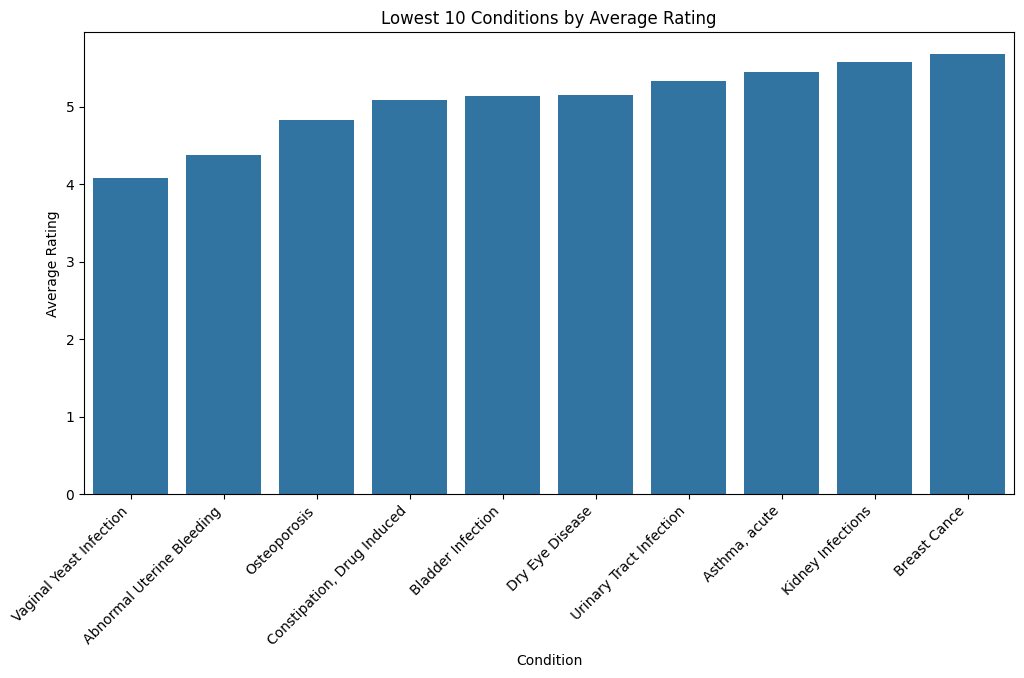

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=lowest_conditions_rating, x='condition', y='average_rating')
plt.title('Lowest 10 Conditions by Average Rating')
plt.xlabel('Condition')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

The lowest average ratings are found in conditions such as Vaginal Yeast Infection, Abnormal Uterine Bleeding, and Osteoporosis. This suggests that users reviewing medications for these conditions were generally less satisfied compared with users reviewing treatments for other conditions. These patterns will be useful later when analyzing sentiment and review text.

**2.6 Useful Count by Rating**

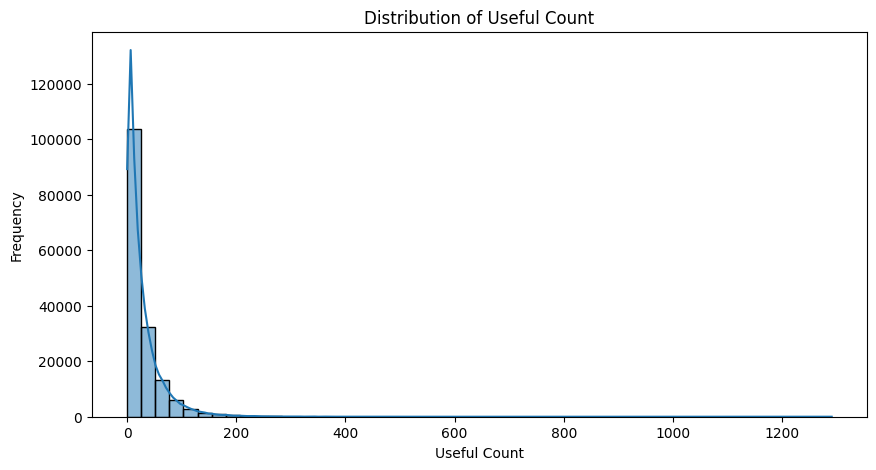

In [ ]:
# Let us first look at the distribution of Useful Count

plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='usefulCount', bins=50, kde=True)
plt.title('Distribution of Useful Count')
plt.xlabel('Useful Count')
plt.ylabel('Frequency')
plt.show()

The usefulCount distribution is highly right-skewed. Most reviews received a relatively small number of usefulness votes, while a few reviews received very high useful counts. This indicates that user engagement is uneven across reviews.

In [ ]:
# Let us group the useful count by its avg

useful_by_rating = train_df.groupby('rating').agg(
    average_useful_count=('usefulCount', 'mean'),
    median_useful_count=('usefulCount', 'median'),
    review_count=('usefulCount', 'count')
).reset_index()

useful_by_rating

,rating,average_useful_count,median_useful_count,review_count
0,1,15.688468,9.0,21619
1,2,16.342952,9.0,6931
2,3,16.035928,9.0,6513
3,4,16.511572,9.0,5012
4,5,17.480719,10.0,8013
5,6,19.910925,12.0,6343
6,7,23.233926,14.0,9456
7,8,29.155903,18.0,18890
8,9,33.577785,22.0,27531
9,10,37.580459,24.0,50989


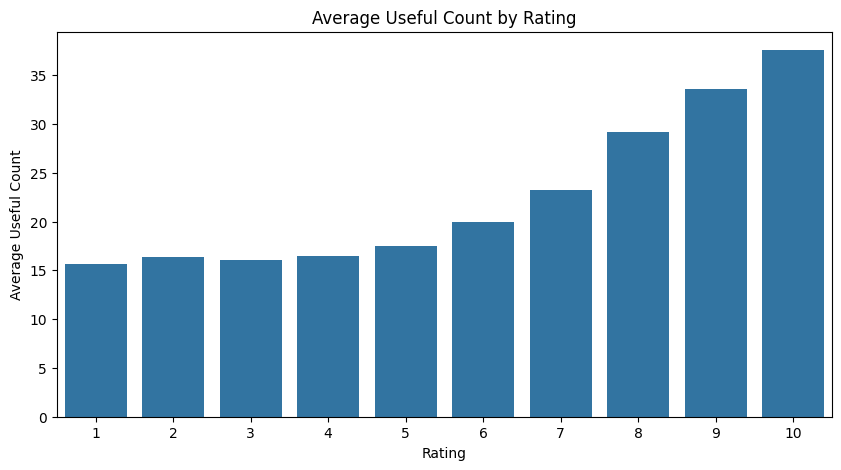

In [ ]:
# Plotting the Average Useful Count

plt.figure(figsize=(10, 5))
sns.barplot(data=useful_by_rating, x='rating', y='average_useful_count')
plt.title('Average Useful Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Useful Count')
plt.show()

The chart shows how the average useful count varies across rating levels. This helps determine whether reviews with certain ratings are more likely to be considered useful by other users. Since usefulCount is right-skewed, the average may be influenced by a small number of highly useful reviews. Therefore, median useful count may also be considered for a more stable comparison.

**2.7 Review Length Distribution**

Review length is important because this project uses text data. By counting the number of words in each review, we can understand whether most reviews are short or detailed. This helps guide the text preprocessing step and gives an idea of how much information is available for sentiment analysis.

In [ ]:
# Lets create a new column that will allow us to review word len characters

eda_df = train_df.copy() # creating a copy so the orig train_df remains unchanged

eda_df['review_word_count'] = eda_df['review'].astype(str).str.split().str.len()

#Checking
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   uniqueID           161297 non-null  int64 
 1   drugName           161297 non-null  object
 2   condition          160398 non-null  object
 3   review             161297 non-null  object
 4   rating             161297 non-null  int64 
 5   date               161297 non-null  object
 6   usefulCount        161297 non-null  int64 
 7   review_word_count  161297 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 9.8+ MB


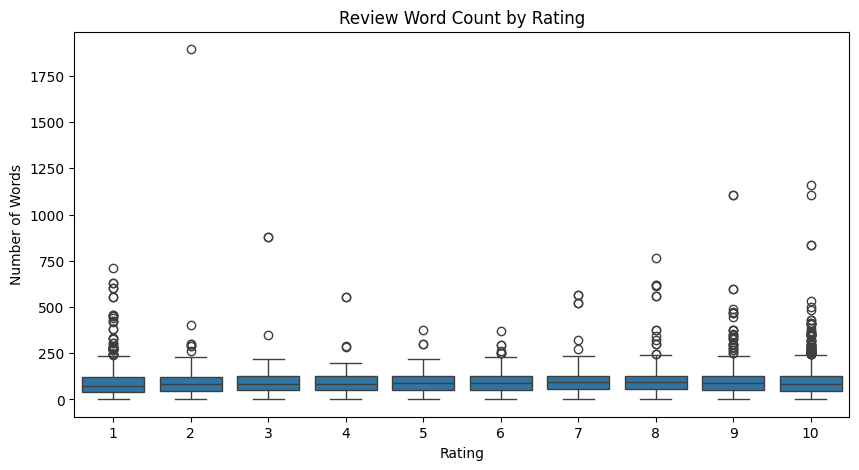

In [ ]:
# Plot

plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x='rating', y='review_word_count')
plt.title('Review Word Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Words')
plt.show()

The boxplot shows the distribution of review word count across rating levels. Overall, the typical review length appears relatively similar across ratings, as the median word counts are close to each other. However, several outliers are present, especially among very low and very high ratings. This suggests that users with strong positive or negative experiences sometimes write much longer and more detailed reviews. These longer reviews may contain important information about effectiveness, side effects, and overall satisfaction, which can be useful for sentiment analysis and text-based modeling.

# 3. Data Cleaning <a name="dc"></a>
    3.1 Check Missing Values
    3.2 Remove Missing Values
    3.3 Check Duplicate Records
    3.4 Remove Invalid Condition Values
    3.5 Clean HTML Entities in Review Text
    3.6 Convert Date Column to Datetime
    3.7 Standardize Text Columns
    3.8 Check Data Types
    3.9 Final Cleaned Dataset Summary

**3.1 Check Missing Values**

In [ ]:
train_df.isnull().sum()
test_df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,295
review,0
rating,0
date,0
usefulCount,0


Missing values can affect analysis and modeling. In this dataset, missing values are mainly expected in the condition column.

In [ ]:
print("Missing values in TRAINING dataset:")
print(train_df.isnull().sum())

print("\nMissing values in TESTING dataset:")
print(test_df.isnull().sum())

Missing values in TRAINING dataset:
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

Missing values in TESTING dataset:
uniqueID         0
drugName         0
condition      295
review           0
rating           0
date             0
usefulCount      0
dtype: int64


**3.2 Remove Missing Values**

Condition is important, we can remove rows with missing condition values.

In [ ]:
train_df = train_df.dropna(subset=['condition', 'review'])
test_df = test_df.dropna(subset=['condition', 'review'])

**3.3 Check Duplicate Records**

In [ ]:
train_df.duplicated().sum()
test_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

In [ ]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


**3.4 Remove Invalid Condition Values**

In [ ]:
train_df = train_df[
    ~train_df['condition'].str.contains('users found this comment helpful', na=False)
]

test_df = test_df[
    ~test_df['condition'].str.contains('users found this comment helpful', na=False)
]

These values are not valid medical conditions and may come from scraped website text. Removing them improves the reliability of condition-based analysis.

**3.5 Clean HTML Entities in Review Text**

In [ ]:
import html

train_df['review'] = train_df['review'].apply(html.unescape)
test_df['review'] = test_df['review'].apply(html.unescape)

**3.6 Convert Date Column to Datetime**

In [ ]:
import pandas as pd

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

In [ ]:
train_df['date'].isnull().sum()
test_df['date'].isnull().sum()

np.int64(0)

Converting the date column allows time-based analysis and ensures the column has the correct data type.

**3.7 Standardize Text Columns**

In [ ]:
# Let us Remove extra spaces from the ff columns

text_cols = ['drugName', 'condition', 'review']

for col in text_cols:
    train_df[col] = train_df[col].astype(str).str.strip()
    test_df[col] = test_df[col].astype(str).str.strip()

**3.8 Check Data Types**

In [ ]:
train_df.info()

test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159498 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   uniqueID     159498 non-null  int64         
 1   drugName     159498 non-null  object        
 2   condition    159498 non-null  object        
 3   review       159498 non-null  object        
 4   rating       159498 non-null  int64         
 5   date         159498 non-null  datetime64[ns]
 6   usefulCount  159498 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 9.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 53200 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   uniqueID     53200 non-null  int64         
 1   drugName     53200 non-null  object        
 2   condition    53200 non-null  object        
 3   review       53200 non-

**3.9 Final Cleaned Dataset Summary**

In [ ]:
print("Training dataset shape after cleaning:", train_df.shape)
print("Testing dataset shape after cleaning:", test_df.shape)

print("\nMissing values after cleaning:")
print(train_df.isnull().sum())

Training dataset shape after cleaning: (159498, 7)
Testing dataset shape after cleaning: (53200, 7)

Missing values after cleaning:
uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64


The data cleaning process focused on improving the quality and consistency of the drug review dataset before preprocessing and modeling.

1. Missing values in important columns such as condition and review were removed because these fields are essential for analysis.
2. Duplicate records were checked and removed to avoid repeated observations.
3. Invalid condition values containing text such as “users found this comment helpful” were removed because they do not represent real medical conditions.
4. HTML entities in the review text were decoded to make the text more readable and suitable for NLP processing.
5. Finally, text columns were stripped of extra spaces and the date column was converted into datetime format.

# 4. Data Preprocessing <a name="proc"></a>

This section prepares the review text for natural language processing and machine learning. The original `review` column contains raw patient-written text, so preprocessing is needed to reduce noise and standardize the text. The cleaned text will be stored in a new column called `clean_review`, while the original review text will be preserved for reference.

    4.1 Separate Feature Types
    4.2 Text Preprocessing
    4.3 Categorical Encoding
    4.4 Numerical Scaling
    4.5 Final Preprocessed Features

**4.1 Separate Feature Types**

Identify which columns are text, categorical, numerical, and not useful for modeling.

In [ ]:
text_feature = 'review'
categorical_features = ['drugName', 'condition']
numerical_features = ['usefulCount']

- Rating column will become my target or sentiment label, so its not included as an input feature.
- UniqueID column is just an identifier.

**4.2 Text Preprocessing <a name="clean"></a>**

Clean the review text before converting it into numerical features

In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = set(ENGLISH_STOP_WORDS) - {'no', 'not', 'never', 'nor'}
# Use scikit-learn’s stopword list, but remove no, not, never, and nor from the stopword list so they will be kept in the reviews.

def clean_review_text(text):
    text = str(text).lower() #converts the review into text and makes it lowercase.
    text = re.sub(r'[^a-z\s]', ' ', text) # This removes punctuation, numbers, and special characters.
    text = re.sub(r'\s+', ' ', text).strip() # removes spaces at the beginning and end.

    words = text.split() # This splits the sentence into words.
    words = [word for word in words if word not in custom_stop_words] # Keep each word only if it is not in the stopword list.

    return ' '.join(words)

The re library was used to remove punctuation, numbers, and special characters from the review text. The ENGLISH_STOP_WORDS list from scikit-learn was used to remove common English words that do not add much meaning. However, negation words such as not, no, never, and nor were kept because they are important for sentiment analysis.

In [ ]:
processed_train_df = train_df.copy()
processed_test_df = test_df.copy()

processed_train_df['clean_review'] = processed_train_df['review'].apply(clean_review_text)
processed_test_df['clean_review'] = processed_test_df['review'].apply(clean_review_text)

# This creates a cleaned version of the review text while preserving the original review column.

**Remember:**

re
→ cleans text using patterns

ENGLISH_STOP_WORDS
→ gives a list of common English words to remove

custom_stop_words
→ stopwords list, but keeps no/not/never/nor

clean_review_text()
→ function that cleans every review


**4.3 Categorical Encoding**

Convert categorical columns into numeric features.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['condition']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(processed_train_df[categorical_features]) # used on the training data because the encoder learns the categories from train.
encoded_test = encoder.transform(processed_test_df[categorical_features]) # used on the test data because the test data should follow the same encoding learned from train.


**4.4 Numerical Scaling**

Scale numerical columns so they are on a similar range.

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['usefulCount']

scaler = StandardScaler()

scaled_train = scaler.fit_transform(processed_train_df[numerical_features])
scaled_test = scaler.transform(processed_test_df[numerical_features])

# Same rule: fit_transform for train then transform for the test. The scaler learns the mean and standard deviation from the training data only.

**4.5 Final Preprocessed Features**

After preprocessing, the dataset contains features that are ready for the next stages of the project, including sentiment analysis, dimensionality reduction, and clustering.

The original `review` column was preserved because the RoBERTa sentiment model works best with natural sentence structure. A cleaned version of the review text was stored in a new column called `clean_review`. This cleaned text will later be converted into numerical features using TF-IDF for dimensionality reduction and clustering.

The `condition` column was converted into numerical values using OneHotEncoder, and the `usefulCount` column was scaled using StandardScaler. These steps show how categorical and numerical features can be prepared for machine learning tasks. The `rating` column was preserved and will be used for comparison with the RoBERTa sentiment results.

The final preprocessed feature groups are:

- `review`: original review text used for RoBERTa sentiment analysis.
- `clean_review`: cleaned text data that will later be converted into numerical features using TF-IDF.
- `encoded_train` and `encoded_test`: one-hot encoded condition features.
- `scaled_train` and `scaled_test`: scaled numerical useful count features.
- `rating`: preserved for comparison with sentiment results.


**TF-IDF**  is a method for converting text into numbers. It gives higher importance to words that are frequent in a specific review but not too common across all reviews. It will be used later because dimensionality reduction and clustering methods cannot directly process raw text.


In [ ]:
print("Cleaned review feature:")
print("Train:", processed_train_df['clean_review'].shape)
print("Test:", processed_test_df['clean_review'].shape)

print("\nEncoded categorical features:")
print("Train:", encoded_train.shape)
print("Test:", encoded_test.shape)

print("\nScaled numerical features:")
print("Train:", scaled_train.shape)
print("Test:", scaled_test.shape)

print("\nProcessed Train and Test shape:")
print("Processed train shape:", processed_train_df.shape)
print("Processed test shape:", processed_test_df.shape)

Cleaned review feature:
Train: (159498,)
Test: (53200,)

Encoded categorical features:
Train: (159498, 811)
Test: (53200, 811)

Scaled numerical features:
Train: (159498, 1)
Test: (53200, 1)

Processed Train and Test shape:
Processed train shape: (159498, 8)
Processed test shape: (53200, 8)


This summarizes the features prepared after preprocessing. I created a cleaned review column for later TF-IDF and clustering. I also encoded the condition column, which produced 811 condition-based features, and scaled usefulCount as a numerical feature. The final processed train and test datasets kept 8 columns, including the original review and the new clean_review column. For RoBERTa, I will use the original review text because RoBERTa works better with natural language.


# 5. Sentiment Analysis using RoBERTa <a name="sdp"></a>

    5.1 Create Random Sample for Sentiment Analysis
    5.2 Load RoBERTa Sentiment Model
    5.3 Test the Model on Sample Text
    5.4 Apply RoBERTa to Drug Reviews
    5.5 RoBERTa sentiment analysis section

**5.1 Create Random Sample for Sentiment Analysis**

The processed training dataset contains a large number of reviews. Since RoBERTa is a transformer-based model and can be computationally expensive, a random sample was used for sentiment analysis. A fixed random state was used to make the sample reproducible.


In [ ]:
sample_size = 1000

sentiment_df = processed_train_df.sample(n=sample_size, random_state=42).copy()

sentiment_df.shape

(1000, 8)

**5.2 Load RoBERTa Sentiment Model**

A pre-trained RoBERTa sentiment model was used to classify review text into negative, neutral, or positive sentiment. Since the model is already trained, it can be applied directly to the review text without training a new model from scratch.


In [ ]:
from transformers import pipeline

In [ ]:
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment"

classifier = pipeline("sentiment-analysis", model=sentiment_model, tokenizer=sentiment_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**5.3  Test the Model on Sample Text**

In [ ]:
sample_text = "This medication worked well and helped me feel better."
classifier(sample_text)

[{'label': 'LABEL_2', 'score': 0.9568213820457458}]

In [ ]:
label_mapping = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

In [ ]:
sample_result = classifier(sample_text)[0]

print("Original label:", sample_result['label'])
print("Sentiment:", label_mapping[sample_result['label']])
print("Confidence score:", sample_result['score'])

Original label: LABEL_2
Sentiment: positive
Confidence score: 0.9568213820457458


The model returns a label and confidence score.

The labels were mapped into readable sentiment categories: negative, neutral, and positive.


**5.4 Apply RoBERTa to Drug Reviews <a name="clean"></a>**

The original `review` column was used for RoBERTa sentiment analysis instead of `clean_review` because transformer models are designed to understand natural sentence structure and context.

The cleaned review text removes punctuation, numbers, and common words, which is useful for TF-IDF and clustering, but may remove context that RoBERTa can use for sentiment prediction.



In [ ]:
processed_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159498 entries, 0 to 161296
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   uniqueID      159498 non-null  int64         
 1   drugName      159498 non-null  object        
 2   condition     159498 non-null  object        
 3   review        159498 non-null  object        
 4   rating        159498 non-null  int64         
 5   date          159498 non-null  datetime64[ns]
 6   usefulCount   159498 non-null  int64         
 7   clean_review  159498 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 11.0+ MB


In [ ]:
# Make sure review text is string

processed_train_df['review'] = processed_train_df['review'].fillna("").astype(str)

In [ ]:
# Create a smaller random sample 5.1

sentiment_df = processed_train_df.sample(n=sample_size, random_state=42).copy()

# Run the classifier

results = classifier(sentiment_df['review'].to_list(), truncation=True) # NB Truncation : If the review is too long, shorten it automatically so the model can process it.

In [ ]:
# Save labels and scores
# Take each model result. Get the label / score. Save it in sentiment_label / sentiment_score.

sentiment_df['sentiment_label'] = [result['label'] for result in results]
sentiment_df['sentiment_score'] = [result['score'] for result in results]

In [ ]:
sentiment_df['roberta_sentiment'] = sentiment_df['sentiment_label'].map(label_mapping)

In [ ]:
sentiment_df[['drugName', 'condition', 'review', 'rating', 'sentiment_label', 'roberta_sentiment', 'sentiment_score']].head()

,drugName,condition,review,rating,sentiment_label,roberta_sentiment,sentiment_score
65940,Lurasidone,Bipolar Disorde,"""I am taking this for bipolar. I'm not taking it in any combination of other meds. So far I have had only good results. I was told it could have sedative affects but the opposite has been true wit...",7,LABEL_2,positive,0.806959
86322,Levomilnacipran,Major Depressive Disorde,"""I have had depression for about 13 years know or I guess it started out as anxiety. I have been on every medication you can name. Most had side effects and had to be switched but nothing serious....",3,LABEL_0,negative,0.833118
39951,Colchicine,"Gout, Acute","""... but my side effects from colchicine were terrible - the doc had put me on 2 x 5mg and then 5mg every 6 hours. \r\n\r\n24 hours later I had spontaneous diarrhoea and vomiting for 36 hours - u...",7,LABEL_0,negative,0.794726
57787,Carvedilol,Atrial Fibrillation,"""Have Tried metropol, tried verapamil now carvedilol. \r\r\nI am getting horrible side effects again. Waking with headache in morning and it just stays all day. Panadol doesn't relieve it. My ears...",3,LABEL_0,negative,0.964381
79097,NuvaRing,Birth Control,"""I've been on Nuvaring just over three months and I love it. Had a little weight gain at the beginning but that can happen with all birth controls. I only just had my first period on it and it was...",8,LABEL_2,positive,0.978913


**5.5 RoBERTa sentiment analysis section**

      1. Sentiment Distribution
      2. Top 10 Drugs by Negative Review Percentage
      3. Top 10 Drugs by Positive Review Percentage
      4. Number of Reviews Over Time
      5. Sentiment Percentage Over Time

**1. Sentiment Distribution**

In [ ]:
#Count total reviews per drug
total_reviews = sentiment_df['drugName'].value_counts()


**2. Top 10 Drugs by Negative Review Percentage**

In [ ]:
#Filter negative reviews
negative_reviews_df = sentiment_df[sentiment_df['roberta_sentiment'] == 'negative']

#Count negative reviews per drug
negative_reviews = negative_reviews_df['drugName'].value_counts()

In [ ]:
drug_negative_summary = pd.DataFrame({'total_reviews': total_reviews,'negative_reviews': negative_reviews})

drug_negative_summary = drug_negative_summary.fillna(0)

drug_negative_summary['negative_percentage'] = (drug_negative_summary['negative_reviews'] / drug_negative_summary['total_reviews']) * 100

drug_negative_summary = drug_negative_summary[drug_negative_summary['total_reviews'] >= 5]

In [ ]:
top_negative_drugs = drug_negative_summary.sort_values(by='negative_percentage',ascending=False).head(10)

top_negative_drugs

,total_reviews,negative_reviews,negative_percentage
drugName,,,
Depo-Provera,7,6.0,85.714286
Medroxyprogesterone,5,4.0,80.000000
Metronidazole,8,6.0,75.000000
Tioconazole,7,5.0,71.428571
Ethinyl estradiol / norethindrone,17,12.0,70.588235
Nexplanon,9,6.0,66.666667
Skyla,9,6.0,66.666667
Ethinyl estradiol / levonorgestrel,11,7.0,63.636364
Bupropion,8,5.0,62.500000


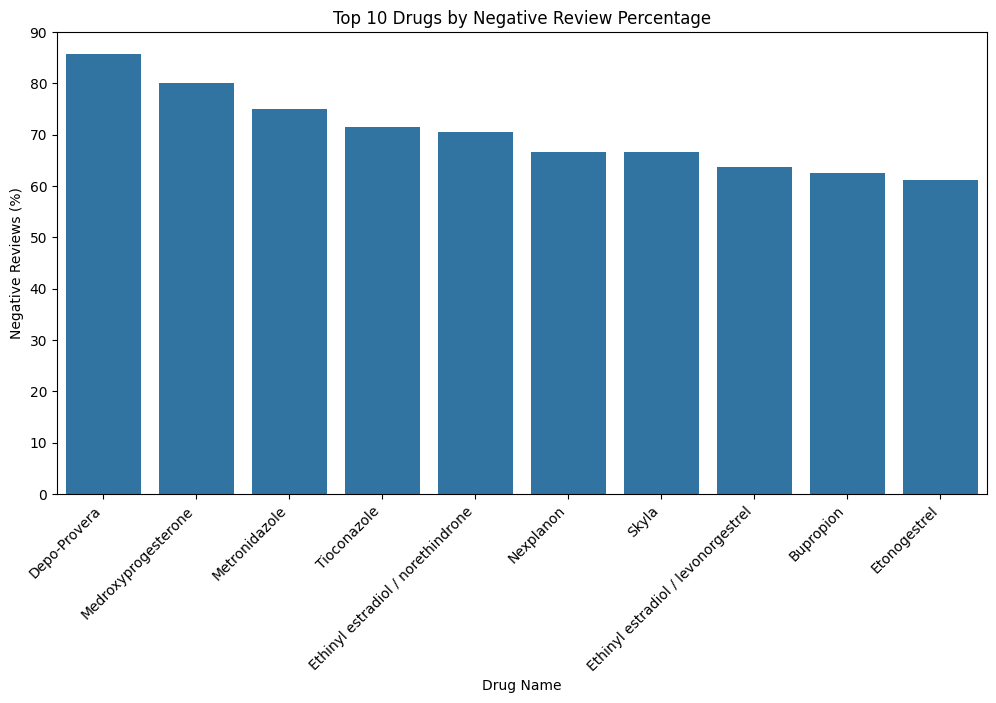

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_negative_drugs,
    x=top_negative_drugs.index,
    y='negative_percentage'
)
plt.title('Top 10 Drugs by Negative Review Percentage')
plt.xlabel('Drug Name')
plt.ylabel('Negative Reviews (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

The chart shows the top 10 drugs with the highest percentage of negative RoBERTa sentiment in the sample. The percentage was calculated by dividing the number of negative reviews by the total number of reviews for each drug. Drugs with fewer than five reviews were removed to reduce misleading results from very small sample sizes.


**3. Top 10 Drugs by Positive Review Percentage**

In [ ]:
positive_reviews_df = sentiment_df[sentiment_df['roberta_sentiment'] == 'positive']

positive_reviews = positive_reviews_df['drugName'].value_counts()

In [ ]:
drug_positive_summary = pd.DataFrame({'total_reviews': total_reviews,'positive_reviews': positive_reviews})

drug_positive_summary = drug_positive_summary.fillna(0)

drug_positive_summary['positive_percentage'] = (drug_positive_summary['positive_reviews'] / drug_positive_summary['total_reviews']) * 100

drug_positive_summary = drug_positive_summary[drug_positive_summary['total_reviews'] >= 5]

In [ ]:
top_positive_drugs = drug_positive_summary.sort_values(by='positive_percentage',ascending=False).head(10)

top_positive_drugs

,total_reviews,positive_reviews,positive_percentage
drugName,,,
Alprazolam,5,5.0,100.000000
Pristiq,7,6.0,85.714286
Fluoxetine,5,4.0,80.000000
Minocycline,5,4.0,80.000000
Phentermine,15,12.0,80.000000
Drospirenone / ethinyl estradiol,8,6.0,75.000000
Sprintec,6,4.0,66.666667
Pregabalin,6,4.0,66.666667
Lyrica,5,3.0,60.000000


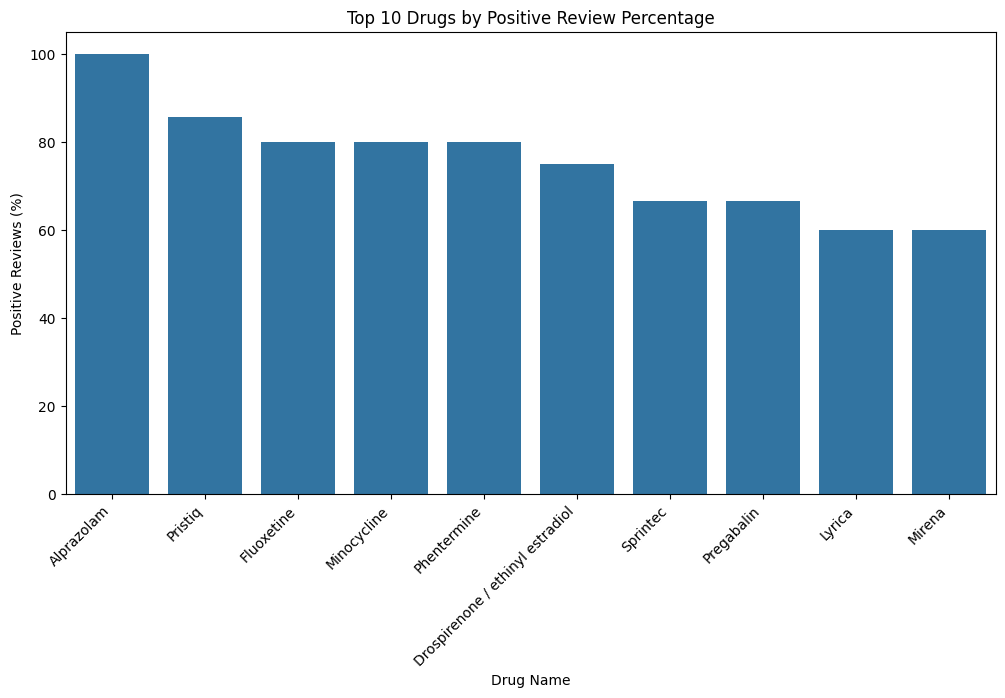

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_positive_drugs,
    x=top_positive_drugs.index,
    y='positive_percentage'
)
plt.title('Top 10 Drugs by Positive Review Percentage')
plt.xlabel('Drug Name')
plt.ylabel('Positive Reviews (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

The chart shows the top 10 drugs with the highest percentage of positive RoBERTa sentiment in the sample. This helps identify drugs where a larger share of reviews expressed positive patient experiences. The analysis used percentages instead of raw counts to make the comparison fairer across drugs with different numbers of reviews.


**4. Number of Reviews Over Time**

How many reviews were posted over time?

In [ ]:
# Convert date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

# Extract year
sentiment_df['year'] = sentiment_df['date'].dt.year

In [ ]:
# Count reviews by year
reviews_per_year = sentiment_df['year'].value_counts().sort_index()

reviews_per_year

,count
year,
2008,27
2009,74
2010,56
2011,70
2012,50
2013,63
2014,70
2015,183
2016,243


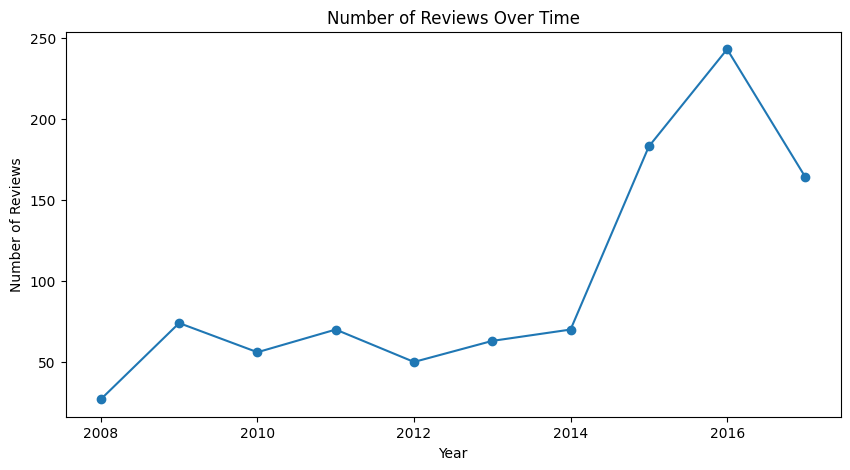

In [ ]:
plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind='line', marker='o')
plt.title('Number of Reviews Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

The line chart shows the number of reviews posted each year in the sampled dataset. This helps identify whether review activity increased or decreased over time. Since the analysis uses a random sample (n=1000), the trend should be interpreted as an approximate pattern rather than the exact full-dataset review volume.


**5. Sentiment Percentage Over Time**

How did negative, neutral, and positive sentiment percentages change over time?

In [ ]:
# Count reviews by year and sentiment

sentiment_by_year = pd.crosstab(sentiment_df['year'], sentiment_df['roberta_sentiment'])

sentiment_by_year

roberta_sentiment,negative,neutral,positive
year,,,
2008,3,4,20
2009,16,14,44
2010,18,7,31
2011,21,18,31
2012,24,10,16
2013,17,11,35
2014,20,11,39
2015,72,37,74
2016,128,31,84


In [ ]:
# Convert counts to percentages

sentiment_by_year_percentage = sentiment_by_year.div(sentiment_by_year.sum(axis=1),axis=0) * 100
# For each year, divide each sentiment count by the total reviews for that year.

sentiment_by_year_percentage

roberta_sentiment,negative,neutral,positive
year,,,
2008,11.111111,14.814815,74.074074
2009,21.621622,18.918919,59.459459
2010,32.142857,12.500000,55.357143
2011,30.000000,25.714286,44.285714
2012,48.000000,20.000000,32.000000
2013,26.984127,17.460317,55.555556
2014,28.571429,15.714286,55.714286
2015,39.344262,20.218579,40.437158
2016,52.674897,12.757202,34.567901


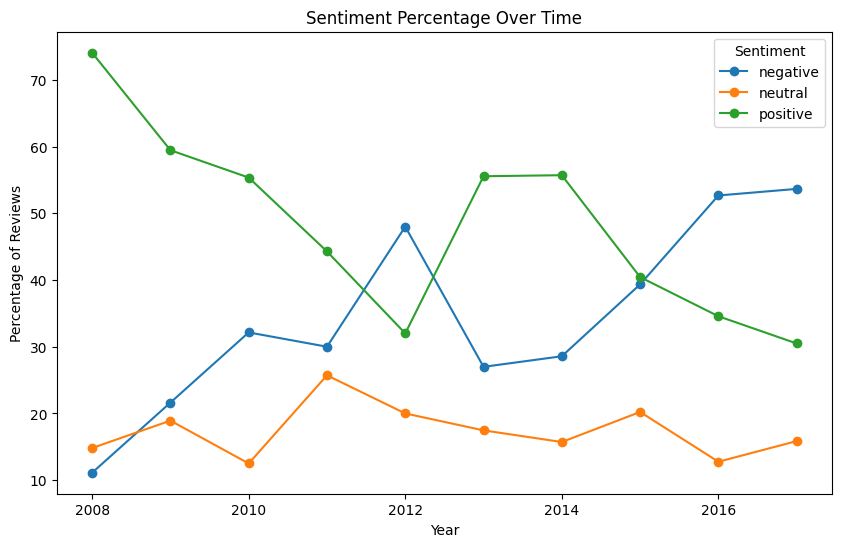

In [ ]:
sentiment_by_year_percentage.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Sentiment Percentage Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of Reviews')
plt.legend(title='Sentiment')
plt.show()

The sentiment percentage over time shows how the share of negative, neutral, and positive reviews changed across years. This provides a clearer view than raw counts because it accounts for differences in the number of reviews per year. Changes in sentiment percentages may reflect shifts in patient experiences, medication usage, or review activity over time.


# 6. Dimensionality Reduction <a name="dimr"></a>

For dimensionality reduction and clustering, the cleaned review text was converted into numerical features using TF-IDF. TF-IDF gives importance to words that appear frequently in a review but are not too common across all reviews.

    6.1 Convert Clean Reviews into TF-IDF Features
    6.2 Apply TruncatedSVD
    6.3 Visualize Reviews in Two Dimensions

**6.1 Convert Clean Reviews into TF-IDF Features**

The cleaned review text was converted into numerical features using TF-IDF. This step is needed because dimensionality reduction methods cannot directly process raw text. TF-IDF gives importance to words based on how often they appear in a review and how unique they are across the dataset.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(sentiment_df['clean_review'].astype(str))

In [ ]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (1000, 3000)


The output means 1000 reviews & 3000 text features

**6.2 Apply TruncatedSVD**

TruncatedSVD was used to reduce the TF-IDF text features into two components. This makes it possible to visualize the reviews in a two-dimensional plot.


In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_2d = TruncatedSVD(n_components=2, random_state=42)

review_2d = svd_2d.fit_transform(tfidf_matrix)

In [ ]:
print("Explained variance ratio:", svd_2d.explained_variance_ratio_)
print("Total explained variance:", svd_2d.explained_variance_ratio_.sum())

Explained variance ratio: [0.0048025  0.01113281]
Total explained variance: 0.015935304525613453


In [ ]:
# component_1 and component_2 are the two new reduced dimensions

sentiment_df['component_1'] = review_2d[:, 0]
sentiment_df['component_2'] = review_2d[:, 1]

Since my features came from TF-IDF text vectorization, I used TruncatedSVD because it works well with sparse text features.

**6.3 Visualize Reviews in Two Dimensions**

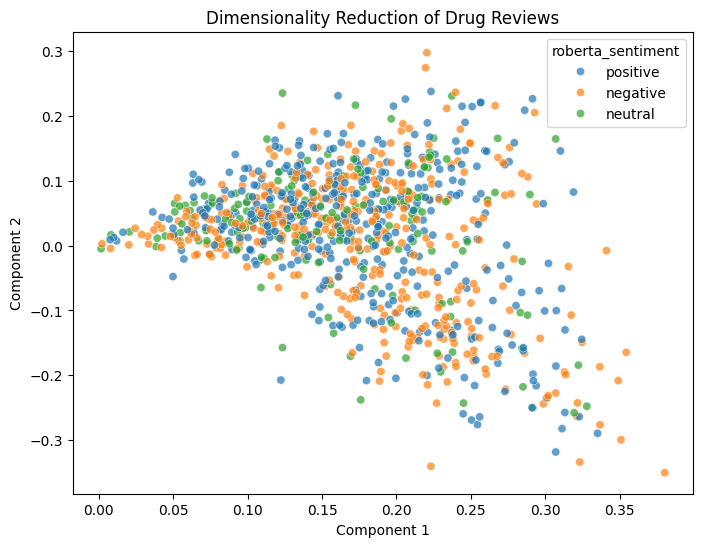

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sentiment_df,
    x='component_1',
    y='component_2',
    hue='roberta_sentiment',
    alpha=0.7
)
plt.title('Dimensionality Reduction of Drug Reviews')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

The scatter plot shows the sampled drug reviews represented in two dimensions after dimensionality reduction. Reviews that are closer together may have more similar word patterns. The colors represent the RoBERTa sentiment predictions, allowing the sentiment groups to be visually compared in the reduced space.


**In my previous learning, I used PCA after encoding categorical variables and scaling numerical variables. In this project, the main feature is text, so I first converted the cleaned reviews into numerical TF-IDF features. Since TF-IDF creates many sparse columns, I used TruncatedSVD to reduce the text features into two components for visualization.**

# 7. Elbow Method <a name="em"></a>

The Elbow Method was used before K-Means clustering to help determine a suitable number of clusters. Since the reviews were already reduced into two dimensions using TruncatedSVD, the `review_2d` output was used in this step.



In [ ]:
from sklearn.cluster import KMeans

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(review_2d)
    inertia_values.append(kmeans_model.inertia_)

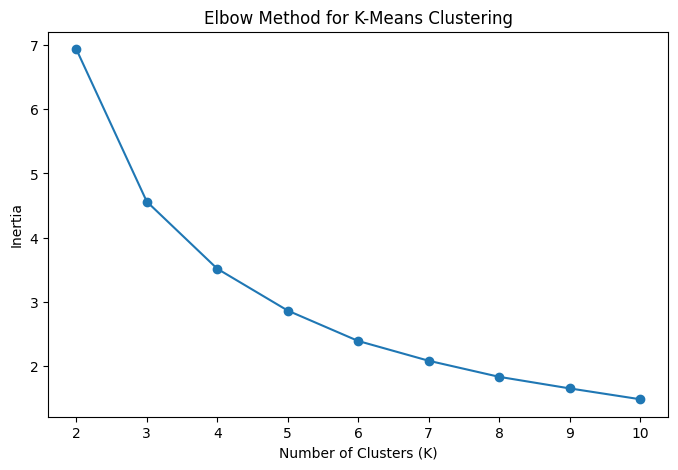

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# optimal_k = 4

# 8. KMeans Clustering <a name="kmean"></a>

K-Means clustering was used to group similar drug reviews based on the reduced text features. The reduced features from TruncatedSVD, stored in `review_2d`, were used as the input for clustering. Each review was assigned to one cluster, allowing the reviews to be segmented into groups with similar text patterns.

    8.1 Apply K-Means Clustering
    8.2 Add Cluster Labels to DataFrame
    8.3 Cluster Counts


**8.1 Apply K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
optimal_k = 4

In [ ]:
kmeans_model = KMeans(n_clusters = 4, random_state=42, n_init=10)

clusters = kmeans_model.fit_predict(review_2d)

**8.2 Add Cluster Labels to DataFrame**

The cluster labels were added to the sentiment DataFrame so each review can be analyzed based on its assigned cluster.


In [ ]:
# the .copy df from the sentiment analysis

sentiment_df['cluster'] = clusters

In [ ]:
sentiment_df[['drugName', 'condition', 'review', 'rating', 'sentiment_label', 'roberta_sentiment', 'sentiment_score']].head()

,drugName,condition,review,rating,sentiment_label,roberta_sentiment,sentiment_score
65940,Lurasidone,Bipolar Disorde,"""I am taking this for bipolar. I'm not taking it in any combination of other meds. So far I have had only good results. I was told it could have sedative affects but the opposite has been true wit...",7,LABEL_2,positive,0.806959
86322,Levomilnacipran,Major Depressive Disorde,"""I have had depression for about 13 years know or I guess it started out as anxiety. I have been on every medication you can name. Most had side effects and had to be switched but nothing serious....",3,LABEL_0,negative,0.833118
39951,Colchicine,"Gout, Acute","""... but my side effects from colchicine were terrible - the doc had put me on 2 x 5mg and then 5mg every 6 hours. \r\n\r\n24 hours later I had spontaneous diarrhoea and vomiting for 36 hours - u...",7,LABEL_0,negative,0.794726
57787,Carvedilol,Atrial Fibrillation,"""Have Tried metropol, tried verapamil now carvedilol. \r\r\nI am getting horrible side effects again. Waking with headache in morning and it just stays all day. Panadol doesn't relieve it. My ears...",3,LABEL_0,negative,0.964381
79097,NuvaRing,Birth Control,"""I've been on Nuvaring just over three months and I love it. Had a little weight gain at the beginning but that can happen with all birth controls. I only just had my first period on it and it was...",8,LABEL_2,positive,0.978913


**8.3 Cluster Counts**

In [ ]:
sentiment_df['cluster'].value_counts().sort_index()

,count
cluster,
0,134
1,295
2,190
3,381


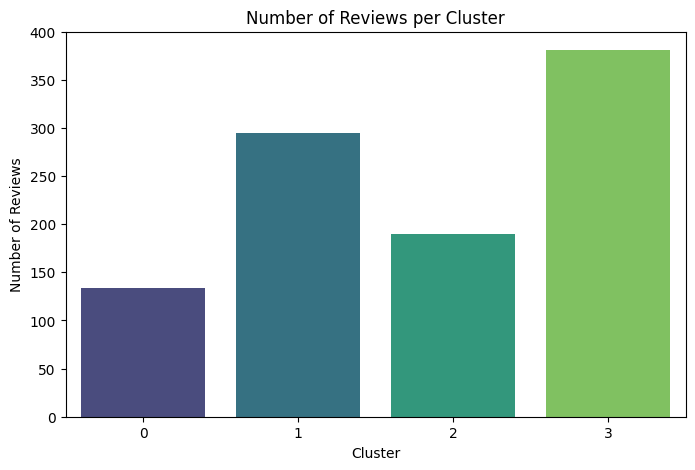

In [ ]:
# plot

plt.figure(figsize=(8, 5))
sns.countplot(
    data=sentiment_df,
    x='cluster',
    palette='viridis'
)
plt.title('Number of Reviews per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.show()

**Insights**

The cluster count shows how many reviews were assigned to each group. This helps identify whether the clustering created balanced groups or whether some clusters contain more reviews than others.


**8.4 Visualize K-Means Clusters**

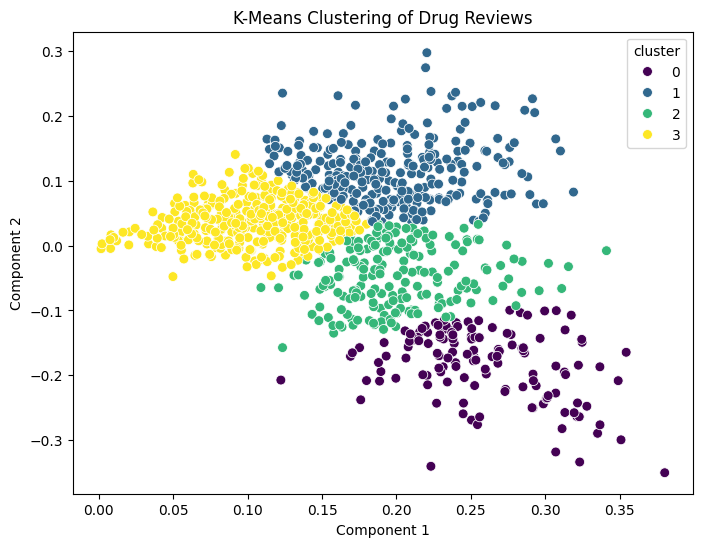

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sentiment_df,
    x='component_1',
    y='component_2',
    hue='cluster',
    palette='viridis',
    s=50
)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('K-Means Clustering of Drug Reviews')
plt.show()

**Insights**

The scatter plot shows the K-Means clusters using the two reduced TruncatedSVD components. Each point represents one drug review, and the color indicates the cluster assigned by K-Means. Reviews in the same cluster are expected to have more similar text patterns.


In [ ]:
sentiment_df['cluster'] = clusters

filt = sentiment_df['cluster'] == 2
sentiment_df[filt]

,uniqueID,drugName,condition,review,rating,date,usefulCount,clean_review,sentiment_label,sentiment_score,roberta_sentiment,year,component_1,component_2,cluster
26127,166393,Levonorgestrel,Abnormal Uterine Bleeding,"""Terrible experience my periods have got so heavy I have not been able to go to work as the super plus tampon and sanitary towel need changing every hour. Twice this week had to change the bedding...",2,2016-11-10,14,terrible experience periods got heavy not able work super plus tampon sanitary towel need changing hour twice week change bedding double sanitary protection does not stop going pyjamas sheets matt...,LABEL_0,0.945539,negative,2016,0.152062,-0.062931,2
89976,135003,Dapsone,Acne,"""I'm 29 years old. Starting at age 13 I started having skin issues that became cystic acne. At 21 I had enough and tried everything. Finally I gave Accutane a try. It completely cleared my skin fo...",9,2016-03-08,5,m years old starting age started having skin issues cystic acne tried finally gave accutane try completely cleared skin years having kids began small breakouts never bad definitely noticeable trie...,LABEL_2,0.788748,positive,2016,0.264884,-0.084790,2
73343,204335,BuSpar,Anxiety,"""I've been on this for about 3 weeks now. At first I thought it was helping my anxiety a bit but then I realized it was just making me tired and loopy after I took it, and that's worn off now (whi...",2,2017-06-27,16,ve weeks thought helping anxiety bit realized just making tired loopy took s worn good realized wasn t helping giving stars didn t hurt tired loopy feeling t orgasm easily appetite gone ve lost we...,LABEL_0,0.425600,negative,2017,0.195965,-0.000269,2
22522,187816,Addyi,Hypoactive Sexual Desire Disorde,"""I've been on Addyi now for 4 weeks and it is working for me! I've went from that dread every time my husband wantedv sex to a great desire for him. I'm finding when I think of sex which I often d...",9,2016-03-01,72,ve addyi weeks working ve went dread time husband wantedv sex great desire m finding think sex m addyi tingling feeling libido went sex twice year times week getting better helped depression plus ...,LABEL_2,0.825582,positive,2016,0.218655,0.022589,2
92262,111346,Ledipasvir / sofosbuvir,Hepatitis C,"""Started Harvoni 6 days ago so far no side effects or maybe a little concentration problem at time. (Brain fog) not sure if thats part of it or just because I'm an old fart LOL.""",3,2016-04-19,7,started harvoni days ago far no effects maybe little concentration problem time brain fog not sure thats just m old fart lol,LABEL_1,0.527170,neutral,2016,0.169476,0.011181,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21921,179643,Adapalene / benzoyl peroxide,Acne,"""My face broke out for a couple months from stress really bad and my doctor gave me epiduo, she said to put it on every night and my acne would probably go away. My acne wasn't going away (somewha...",3,2016-10-15,3,face broke couple months stress really bad doctor gave epiduo said night acne probably away acne wasn t going away somewhat mild used skin awful weeks worse ve frustrated second week awful face st...,LABEL_0,0.924414,negative,2016,0.271608,-0.062497,2
52249,204784,Cyproheptadine,Anorexia,"""I have struggled for years to keep weight on, I am 5'2"" and was 96lbs. None of my clothes have ever looked good on me....People just don't feel sympathy for people that struggle to gain weight. I...",10,2016-01-13,52,struggled years weight lbs clothes looked good people just don t feel sympathy people struggle gain weight s diets losing weight appetite terrible force eat doctor prescribed medication week ago g...,LABEL_0,0.554262,negative,2016,0.235563,0.014004,2
124262,232084,Perampanel,Epilepsy,"""I have generalized epilepsy and very hard to control ... fycompa was working like the magical drug for the first 2 months then all the side effects hit me like a rock , the first was anger I woul...",6,2017-08-28,1,generalized epilepsy hard control 

# 9. Cluster Insights <a name="edac"></a>

    9.1 Number of Reviews per Cluster
    9.2 Sentiment Distribution by Cluster
    9.3 Top Conditions per Cluster
    9.4 Top Drugs per Cluster
    9.5 Sample Reviews per Cluster
    9.6 Cluster Interpretation Summary


**9.1 Number of Reviews per Cluster**

The number of reviews in each cluster was checked to understand how the sampled reviews were distributed across the K-Means groups.


In [ ]:
cluster_counts = sentiment_df['cluster'].value_counts().sort_index()

cluster_counts

,count
cluster,
0,134
1,295
2,190
3,381


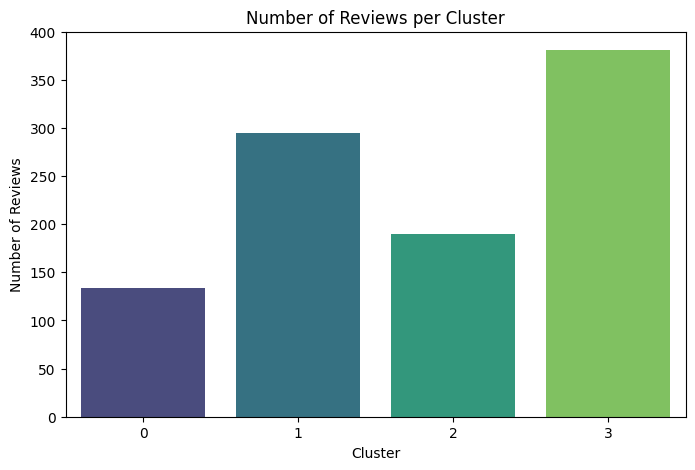

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=sentiment_df,
    x='cluster',
    palette='viridis'
)
plt.title('Number of Reviews per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.show()

The cluster count shows whether the review groups are balanced or whether some clusters contain more reviews than others. Larger clusters may represent more common review patterns in the sampled dataset.

**9.2 Sentiment Distribution by Cluster**

The RoBERTa sentiment results were compared across clusters to understand the emotional tone of each review segment.


In [ ]:
cluster_sentiment = pd.crosstab(sentiment_df['cluster'], sentiment_df['roberta_sentiment'])

cluster_sentiment

roberta_sentiment,negative,neutral,positive
cluster,,,
0,67,15,52
1,111,49,135
2,80,27,83
3,149,78,154


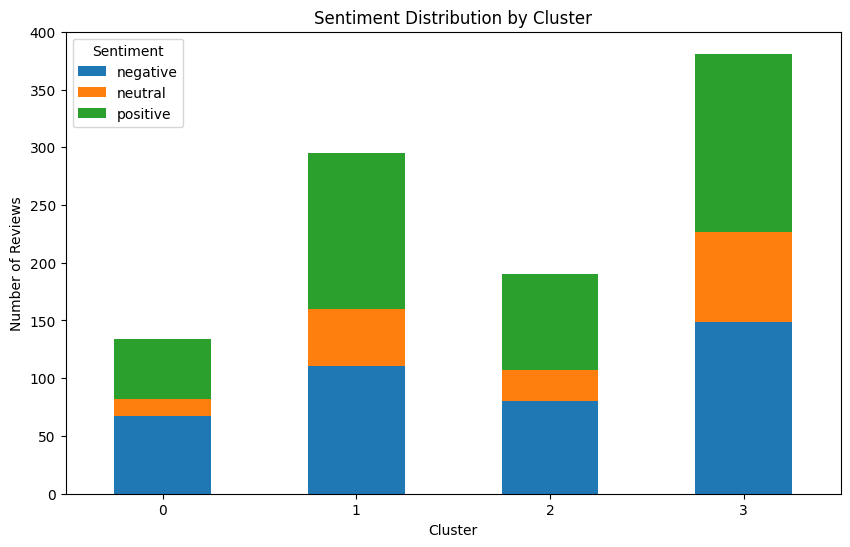

In [ ]:
cluster_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Sentiment Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

In [ ]:
cluster_sentiment_percentage = cluster_sentiment.div(cluster_sentiment.sum(axis=1), axis=0) * 100

cluster_sentiment_percentage

roberta_sentiment,negative,neutral,positive
cluster,,,
0,50.000000,11.194030,38.805970
1,37.627119,16.610169,45.762712
2,42.105263,14.210526,43.684211
3,39.107612,20.472441,40.419948


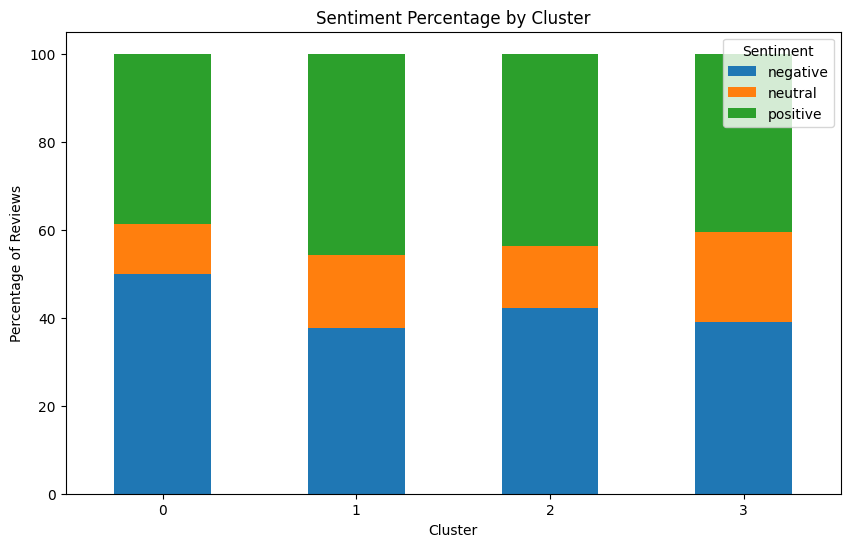

In [ ]:
cluster_sentiment_percentage.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Sentiment Percentage by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

The sentiment distribution by cluster shows whether each cluster is mostly positive, negative, or neutral. This helps describe the emotional pattern of each group of reviews.


**9.3 Top Conditions per Cluster**

The most common medical conditions in each cluster were reviewed to understand what types of patient experiences are grouped together.

In [ ]:
for cluster_num in sorted(sentiment_df['cluster'].unique()):
    print(f"Cluster {cluster_num} - Top Conditions")
    print(sentiment_df[sentiment_df['cluster'] == cluster_num]['condition'].value_counts().head(5))
    print("-" * 60)

Cluster 0 - Top Conditions
condition
Birth Control                111
Abnormal Uterine Bleeding     11
Acne                           6
Emergency Contraception        2
Menstrual Disorders            1
Name: count, dtype: int64
------------------------------------------------------------
Cluster 1 - Top Conditions
condition
Depression    31
Pain          27
Anxiety       20
Insomnia      15
ADHD          11
Name: count, dtype: int64
------------------------------------------------------------
Cluster 2 - Top Conditions
condition
Birth Control              77
Acne                       26
Weight Loss                15
Obesity                    12
Emergency Contraception     9
Name: count, dtype: int64
------------------------------------------------------------
Cluster 3 - Top Conditions
condition
Depression    20
Anxiety       13
Pain          12
ADHD          12
Acne          10
Name: count, dtype: int64
------------------------------------------------------------


The top conditions help explain the possible medical themes of each cluster. For example, a cluster may contain many reviews related to Birth Control, Depression, Pain, or Anxiety.


**9.4 Top Drugs per Cluster**

The most common drugs in each cluster were checked to identify which medications appeared frequently in each review group.


In [ ]:
for cluster_num in sorted(sentiment_df['cluster'].unique()):
    print(f"Cluster {cluster_num} -Top Drugs")
    print(sentiment_df[sentiment_df['cluster'] == cluster_num]['drugName'].value_counts().head(5))
    print("-" * 60)

Cluster 0 -Top Drugs
drugName
Levonorgestrel                       14
Ethinyl estradiol / norethindrone    12
Etonogestrel                         11
Implanon                              9
Ethinyl estradiol / norgestimate      7
Name: count, dtype: int64
------------------------------------------------------------
Cluster 1 -Top Drugs
drugName
Amitriptyline    7
Escitalopram     6
Pristiq          6
Duloxetine       6
Mirtazapine      5
Name: count, dtype: int64
------------------------------------------------------------
Cluster 2 -Top Drugs
drugName
Levonorgestrel                      15
Phentermine                         11
Ethinyl estradiol / norgestimate     7
Etonogestrel                         7
NuvaRing                             6
Name: count, dtype: int64
------------------------------------------------------------
Cluster 3 -Top Drugs
drugName
Miconazole     5
Tioconazole    4
Bupropion      4
Oxycodone      4
Doxycycline    4
Name: count, dtype: int64
------------------

The top drugs per cluster provide additional context about the review groups. If certain drugs appear frequently in a cluster, it may indicate that the cluster captures common experiences related to those medications.


**9.5 Sample Reviews per Cluster**

Sample reviews from each cluster were inspected to better understand the type of language, sentiment, and experience represented in each group.

In [ ]:
for cluster_num in sorted(sentiment_df['cluster'].unique()):
    print(f"Cluster {cluster_num} Sample Reviews")

    sample_reviews = sentiment_df[sentiment_df['cluster'] == cluster_num][
        ['review', 'roberta_sentiment', 'rating']
    ].head(3)

    print(sample_reviews.to_string())
    print("-" * 80)

Cluster 0 Sample Reviews
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   review roberta_sentiment  rating
79097                                                                                                                                                                                      

Looking at sample reviews helps give meaning to the clusters. Since K-Means only assigns numerical cluster labels, the actual interpretation comes from examining the reviews, sentiments, conditions, and drugs inside each cluster.


**9.6 Cluster Interpretation Summary**

Based on the cluster analysis, each cluster appears to represent a different group of review patterns. The clusters were interpreted using sentiment distribution, top conditions, top drugs, and sample reviews. Some clusters may contain more positive reviews, while others may include more negative or mixed patient experiences. The cluster labels do not have automatic meanings, so the interpretation is based on the patterns observed within each group.


# 10. Conclusions  <a name= "conc"></a>

This project analyzed patient drug reviews using exploratory data analysis, data preprocessing, RoBERTa sentiment analysis, dimensionality reduction, and K-Means clustering. The dataset contains patient reviews, drug names, medical conditions, ratings, review dates, and useful vote counts.

The initial analysis showed that the dataset contains many reviews related to common conditions such as Birth Control, Depression, Pain, Anxiety, and Acne. The rating distribution showed that many users gave high ratings, but rating 1 was also common, indicating that the dataset includes both strongly positive and strongly negative patient experiences.

After cleaning and preprocessing the dataset, a random sample was selected for RoBERTa sentiment analysis because transformer models require more computational resources. The RoBERTa model classified the sampled reviews into negative, neutral, and positive sentiment categories based on the original review text. The sentiment results helped summarize the overall emotional tone of the patient reviews.

For dimensionality reduction, the cleaned review text was converted into TF-IDF features and reduced into two components using TruncatedSVD. This made it possible to visualize the review text in a two-dimensional space. The Elbow Method was then used to select a suitable number of clusters, and K-Means clustering was applied to group similar reviews together.

The cluster insights showed that each group may represent different review patterns based on sentiment, medical condition, drug name, and review content. By examining cluster counts, sentiment distribution, top conditions, top drugs, and sample reviews, the clusters were interpreted as groups of similar patient experiences.

Overall, this project shows how natural language processing and clustering can be used to explore patient drug reviews. The combination of sentiment analysis and review segmentation provides useful insight into patient satisfaction, common concerns, and patterns in medication experiences.


### Limitations

This project used a random sample of the dataset for RoBERTa sentiment analysis due to computational limitations. Therefore, the sentiment results represent patterns within the sample and may not fully reflect the entire dataset.

The RoBERTa model used in this project was originally trained on social media text, not specifically on medical drug reviews. Because of this, the sentiment predictions should be interpreted as general sentiment estimates rather than medical-domain-specific conclusions.

The clustering results also depend on the selected sample, TF-IDF features, TruncatedSVD components, and chosen number of clusters. Therefore, the clusters should be interpreted as exploratory patterns rather than definitive medical categories.


# Incorporating LLM Model

In [ ]:
# Add LLM model for the Sentiment Analysis / then side by side comparison from the LLM and the other models

In [ ]:
!pip install anthropic pandas

In [ ]:
import pandas as pd
import anthropic
from getpass import getpass

In [ ]:
from getpass import getpass
api_key = getpass("Enter your Anthropic API key: ")

In [ ]:
client = anthropic.Anthropic(api_key=api_key)

In [ ]:
processed_train_df['reviews'] = processed_train_df['review'].fillna("").astype(str)

In [ ]:
processed_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159498 entries, 0 to 161296
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   uniqueID      159498 non-null  int64         
 1   drugName      159498 non-null  object        
 2   condition     159498 non-null  object        
 3   review        159498 non-null  object        
 4   rating        159498 non-null  int64         
 5   date          159498 non-null  datetime64[ns]
 6   usefulCount   159498 non-null  int64         
 7   clean_review  159498 non-null  object        
 8   reviews       159498 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 12.2+ MB


In [ ]:
def llm_sentiment_identifier(review_text):

    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        messages=[
            {
                "role": "user",
                "content": f"""
Classify the sentiment of this drug review as exactly one word:
positive, neutral, or negative.

Review:
{review_text}
"""
            }
        ]
    )
    return response.content[0].text.strip().lower()

In [ ]:
smaller_df = processed_train_df.head(10)

In [ ]:
reviews = smaller_df['reviews'].to_list()
topics = []

for review in reviews:
    sentiment = llm_sentiment_identifier(review)
    topics.append(sentiment)

In [ ]:
llm_df = smaller_df.head(10).copy()

reviews = llm_df['reviews'].tolist()
llm_sentiments = []

for review in reviews:
    sentiment = llm_sentiment_identifier(review)
    llm_sentiments.append(sentiment)

llm_df['llm_sentiment'] = llm_sentiments
llm_df[['reviews', 'llm_sentiment']].head(10)

,reviews,llm_sentiment
0,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",positive
1,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get ou...",positive
2,"""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not ava...",negative
3,"""This is my first time using any form of birth control. I'm glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is that...",positive
4,"""Suboxone has completely turned my life around. I feel healthier, I'm excelling at my job and I always have money in my pocket and my savings account. I had none of those before Suboxone and spe...",positive
5,"""2nd day on 5mg started to work with rock hard erections however experianced headache, lower bowel preassure. 3rd day erections would wake me up & hurt! Leg/ankles aches severe lower bowel preas...",negative
6,"""He pulled out, but he cummed a bit in me. I took the Plan B 26 hours later, and took a pregnancy test two weeks later - - I'm pregnant.""",negative
7,"""Abilify changed my life. There is hope. I was on Zoloft and Clonidine when I first started Abilify at the age of 15.. Zoloft for depression and Clondine to manage my complete rage. My moods were ...",positive
8,""" I Ve had nothing but problems with the Keppera : constant shaking in my arms & legs & pins & needles feeling in my arms & legs severe light headedness no appetite & etc.""",negative
9,"""I had been on the pill for many years. When my doctor changed my RX to chateal, it was as effective. It really did help me by completely clearing my acne, this takes about 6 months though. I did ...",positive


In [ ]:
# Comparison

comparison_df = sentiment_df.head(10).copy()
comparison_df['review'] = comparison_df['review'].fillna("").astype(str)

In [ ]:
def llm_sentiment_identifier(review_text):
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        messages=[
            {
                "role": "user",
                "content": f"""

Classify the sentiment of this drug review as exactly one word:
positive, neutral, or negative.

Review:
{review_text}
"""
            }
        ]
    )
    return response.content[0].text.strip().lower()

In [ ]:
llm_sentiments = []

for review in comparison_df['review'].tolist():
    sentiment = llm_sentiment_identifier(review)
    llm_sentiments.append(sentiment)

comparison_df['claude_sentiment'] = llm_sentiments

In [ ]:
pd.set_option('display.max_colwidth', 200)

comparison_df[
    ['drugName', 'condition', 'review', 'rating', 'roberta_sentiment', 'claude_sentiment']
].head(10)

,drugName,condition,review,rating,roberta_sentiment,claude_sentiment
65940,Lurasidone,Bipolar Disorde,"""I am taking this for bipolar. I'm not taking it in any combination of other meds. So far I have had only good results. I was told it could have sedative affects but the opposite has been true wit...",7,positive,positive
86322,Levomilnacipran,Major Depressive Disorde,"""I have had depression for about 13 years know or I guess it started out as anxiety. I have been on every medication you can name. Most had side effects and had to be switched but nothing serious....",3,negative,negative
39951,Colchicine,"Gout, Acute","""... but my side effects from colchicine were terrible - the doc had put me on 2 x 5mg and then 5mg every 6 hours. \r\n\r\n24 hours later I had spontaneous diarrhoea and vomiting for 36 hours - u...",7,negative,negative
57787,Carvedilol,Atrial Fibrillation,"""Have Tried metropol, tried verapamil now carvedilol. \r\r\nI am getting horrible side effects again. Waking with headache in morning and it just stays all day. Panadol doesn't relieve it. My ears...",3,negative,negative
79097,NuvaRing,Birth Control,"""I've been on Nuvaring just over three months and I love it. Had a little weight gain at the beginning but that can happen with all birth controls. I only just had my first period on it and it was...",8,positive,positive
158943,Phentermine,Weight Loss,"""I went to the doctor on June 23rd and weighed in at 322lbs. I started Phentermine that day and as of this morning I weighed 312. That's 10 pounds in less than a week. I feel great, no problems...",10,positive,positive
26127,Levonorgestrel,Abnormal Uterine Bleeding,"""Terrible experience my periods have got so heavy I have not been able to go to work as the super plus tampon and sanitary towel need changing every hour. Twice this week had to change the bedding...",2,negative,negative
95062,Belsomra,Insomnia,"""Precribed after many years of Ambien use. Took 5 mg.....nothing\r\nAfter an hour 5 more mg........after another hour 5more mg.....tossing and turning . No sleep. Back to Ambien.""",1,negative,negative
74339,Nexplanon,Birth Control,"""I've had my birth control in since January 2015 and I absolutely love it! I use to have very, very long periods. Long as in 3-4 months and it was heavy. Heavy to the point that blood transfusions...",10,positive,positive
89976,Dapsone,Acne,"""I'm 29 years old. Starting at age 13 I started having skin issues that became cystic acne. At 21 I had enough and tried everything. Finally I gave Accutane a try. It completely cleared my skin fo...",9,positive,positive


In [ ]:
pd.crosstab(
    comparison_df['roberta_sentiment'],
    comparison_df['claude_sentiment']
)

claude_sentiment,negative,positive
roberta_sentiment,,
negative,5,0
positive,0,5


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
roberta_counts = comparison_df['roberta_sentiment'].value_counts()
claude_counts = comparison_df['claude_sentiment'].value_counts()

comparison_counts = pd.DataFrame({
    'RoBERTa': roberta_counts,
    'Claude': claude_counts
}).fillna(0)

comparison_counts = comparison_counts.reindex(['negative', 'neutral', 'positive'])
comparison_counts

,RoBERTa,Claude
negative,5.0,5.0
neutral,NaN,NaN
positive,5.0,5.0


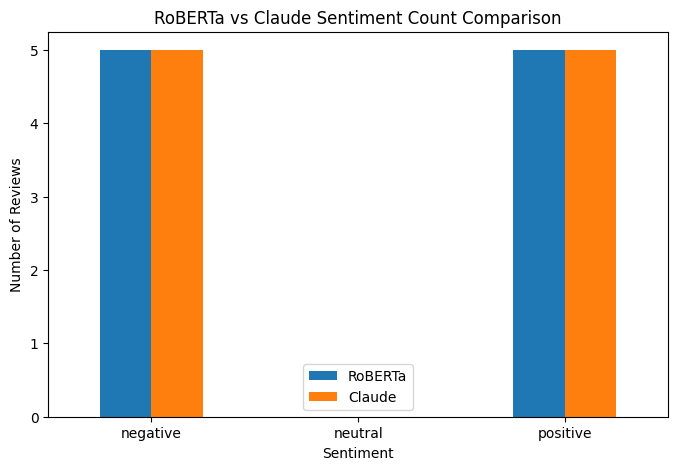

In [ ]:
comparison_counts.plot(kind='bar', figsize=(8,5))
plt.title('RoBERTa vs Claude Sentiment Count Comparison')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

### Side-by-Side RoBERTa vs Claude Comparison

To compare a transformer-based sentiment model and a prompt-based LLM approach, the same sample of reviews was evaluated using both RoBERTa and Claude. RoBERTa produced sentiment labels from the review text, while Claude was prompted to classify each review as positive, neutral, or negative. The predictions were then compared side by side to check whether the two approaches agreed on the sentiment of the same review.


The comparison shows that RoBERTa and Claude often agree on clearly positive or clearly negative reviews, but differences may appear when a review contains mixed experiences or less direct wording. This highlights how different language models can interpret the same review in slightly different ways.
